In [16]:
#Data Exploration & Preprocessing

In [17]:
import pandas as pd

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score,classification_report
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [20]:
# Load the data
df = pd.read_csv('ufc-fighters-statistics.csv')


In [21]:
# Initial exploration
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (4111, 18)

First 5 rows:
                name    nickname  wins  losses  draws  height_cm  \
0    Robert Drysdale         NaN     7       0      0     190.50   
1  Daniel McWilliams  The Animal    15      37      0     185.42   
2         Dan Molina         NaN    13       9      0     177.80   
3          Paul Ruiz         NaN     7       4      0     167.64   
4    Collin Huckbody      All In     8       2      0     190.50   

   weight_in_kg  reach_in_cm    stance date_of_birth  \
0         92.99          NaN  Orthodox    1981-10-05   
1         83.91          NaN       NaN           NaN   
2         97.98          NaN       NaN           NaN   
3         61.23          NaN       NaN           NaN   
4         83.91       193.04  Orthodox    1994-09-29   

   significant_strikes_landed_per_minute  significant_striking_accuracy  \
0                                   0.00                            0.0   
1                                   3.36                       

In [22]:
#Data Cleaning

In [23]:
# 1. Create a copy to work with
ufc_df = df.copy()

# 2. Calculate age from date_of_birth
ufc_df['date_of_birth'] = pd.to_datetime(ufc_df['date_of_birth'], errors='coerce')
ufc_df['age'] = 2024 - ufc_df['date_of_birth'].dt.year

# 3. Create success metrics
ufc_df['total_fights'] = ufc_df['wins'] + ufc_df['losses'] + ufc_df['draws']
ufc_df['win_ratio'] = ufc_df['wins'] / (ufc_df['total_fights'] + 1)  # +1 to avoid division by zero

# Create a binary success target (1 if win_ratio > 0.5, 0 otherwise)
ufc_df['successful'] = (ufc_df['win_ratio'] > 0.5).astype(int)

# 4. Create composite metrics (inspired by research)
# Striking effectiveness: landed vs absorbed
ufc_df['strike_differential'] = (ufc_df['significant_strikes_landed_per_minute'] -
                                 ufc_df['significant_strikes_absorbed_per_minute'])
# Striking efficiency ratio (avoiding division by zero)
ufc_df['striking_efficiency'] = np.where(
    ufc_df['significant_strikes_absorbed_per_minute'] > 0,
    ufc_df['significant_strikes_landed_per_minute'] / ufc_df['significant_strikes_absorbed_per_minute'],
    ufc_df['significant_strikes_landed_per_minute']
)
# Overall takedown effectiveness
ufc_df['takedown_effectiveness'] = ufc_df['average_takedowns_landed_per_15_minutes'] * ufc_df['takedown_accuracy']

# 5. Handle missing values
# Fill numeric columns with median
numeric_cols = ['height_cm', 'weight_in_kg', 'reach_in_cm', 'age',
                'significant_strikes_landed_per_minute', 'significant_striking_accuracy',
                'significant_strikes_absorbed_per_minute', 'significant_strike_defence',
                'average_takedowns_landed_per_15_minutes', 'takedown_accuracy',
                'takedown_defense', 'average_submissions_attempted_per_15_minutes']

for col in numeric_cols:
    ufc_df[col] = ufc_df[col].fillna(ufc_df[col].median())

# Handle stance missing values (fill with 'Unknown')
ufc_df['stance'] = ufc_df['stance'].fillna('Unknown')

# 6. Remove outliers (optional - based on IQR)
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Apply to key columns (be careful not to remove too much data)
for col in ['wins', 'win_ratio', 'age']:
    ufc_df = remove_outliers(ufc_df, col)

print("\nCleaned dataset shape:", ufc_df.shape)


Cleaned dataset shape: (3564, 25)


In [24]:
#Exploratory Data Analysis

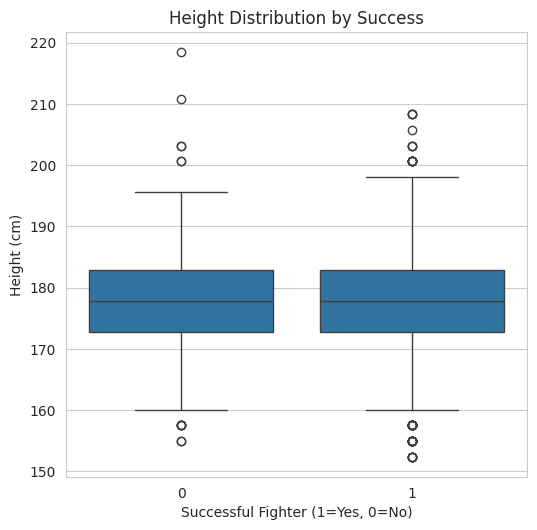

In [25]:
# Set up the visualization style
sns.set_style("whitegrid")
plt.figure(figsize=(15, 10))

# Height distribution by success
plt.subplot(2, 3, 1)
sns.boxplot(x='successful', y='height_cm', data=ufc_df)
plt.title('Height Distribution by Success')
plt.xlabel('Successful Fighter (1=Yes, 0=No)')
plt.ylabel('Height (cm)')

plt.tight_layout()
plt.show()


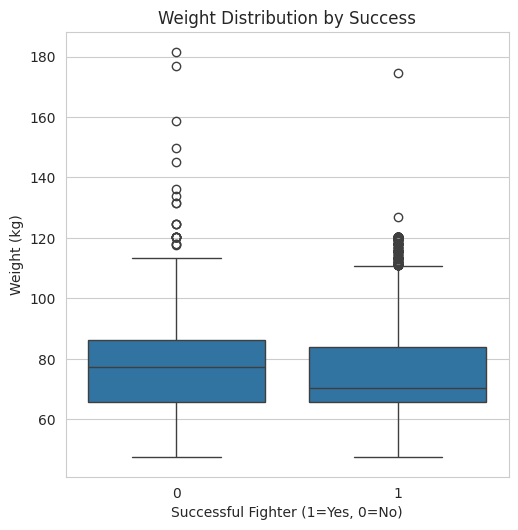

In [26]:
# Set up the visualization style
sns.set_style("whitegrid")
plt.figure(figsize=(15, 10))

# Weight distribution by success
plt.subplot(2, 3, 2)
sns.boxplot(x='successful', y='weight_in_kg', data=ufc_df)
plt.title('Weight Distribution by Success')
plt.xlabel('Successful Fighter (1=Yes, 0=No)')
plt.ylabel('Weight (kg)')

plt.tight_layout()
plt.show()

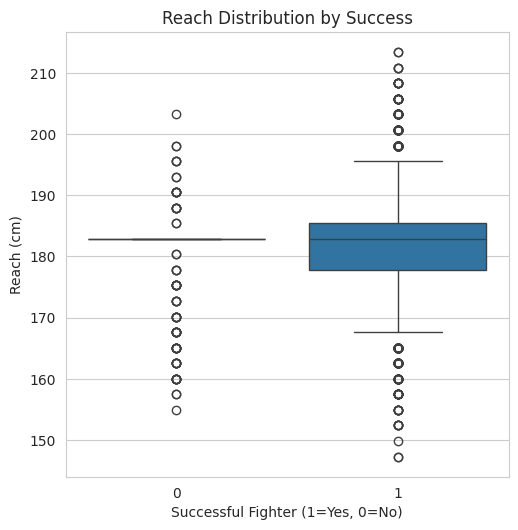

In [27]:
# Set up the visualization style
sns.set_style("whitegrid")
plt.figure(figsize=(15, 10))

# Reach distribution by success
plt.subplot(2, 3, 3)
sns.boxplot(x='successful', y='reach_in_cm', data=ufc_df)
plt.title('Reach Distribution by Success')
plt.xlabel('Successful Fighter (1=Yes, 0=No)')
plt.ylabel('Reach (cm)')

plt.tight_layout()
plt.show()

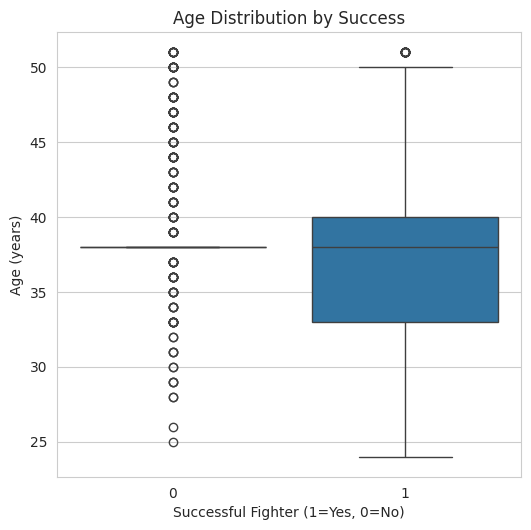

In [28]:
# Set up the visualization style
sns.set_style("whitegrid")
plt.figure(figsize=(15, 10))

# Age distribution by success
plt.subplot(2, 3, 4)
sns.boxplot(x='successful', y='age', data=ufc_df)
plt.title('Age Distribution by Success')
plt.xlabel('Successful Fighter (1=Yes, 0=No)')
plt.ylabel('Age (years)')

plt.tight_layout()
plt.show()

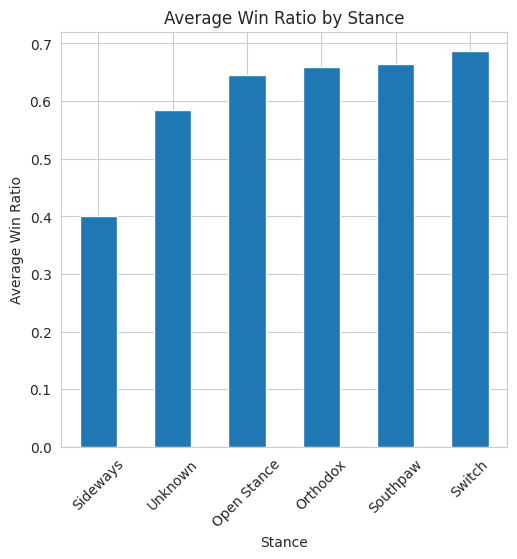

In [29]:
# Set up the visualization style
sns.set_style("whitegrid")
plt.figure(figsize=(15, 10))

# Stance analysis
plt.subplot(2, 3, 5)
stance_success = ufc_df.groupby('stance')['win_ratio'].mean().sort_values()
stance_success.plot(kind='bar')
plt.title('Average Win Ratio by Stance')
plt.xlabel('Stance')
plt.ylabel('Average Win Ratio')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

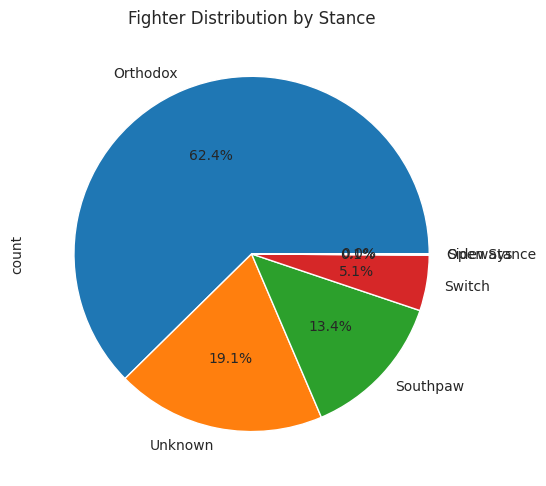

In [30]:
# Set up the visualization style
sns.set_style("whitegrid")
plt.figure(figsize=(15,10))

plt.subplot(2, 3, 6)
# Count of fighters by stance
ufc_df['stance'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Fighter Distribution by Stance')

plt.tight_layout()
plt.show()

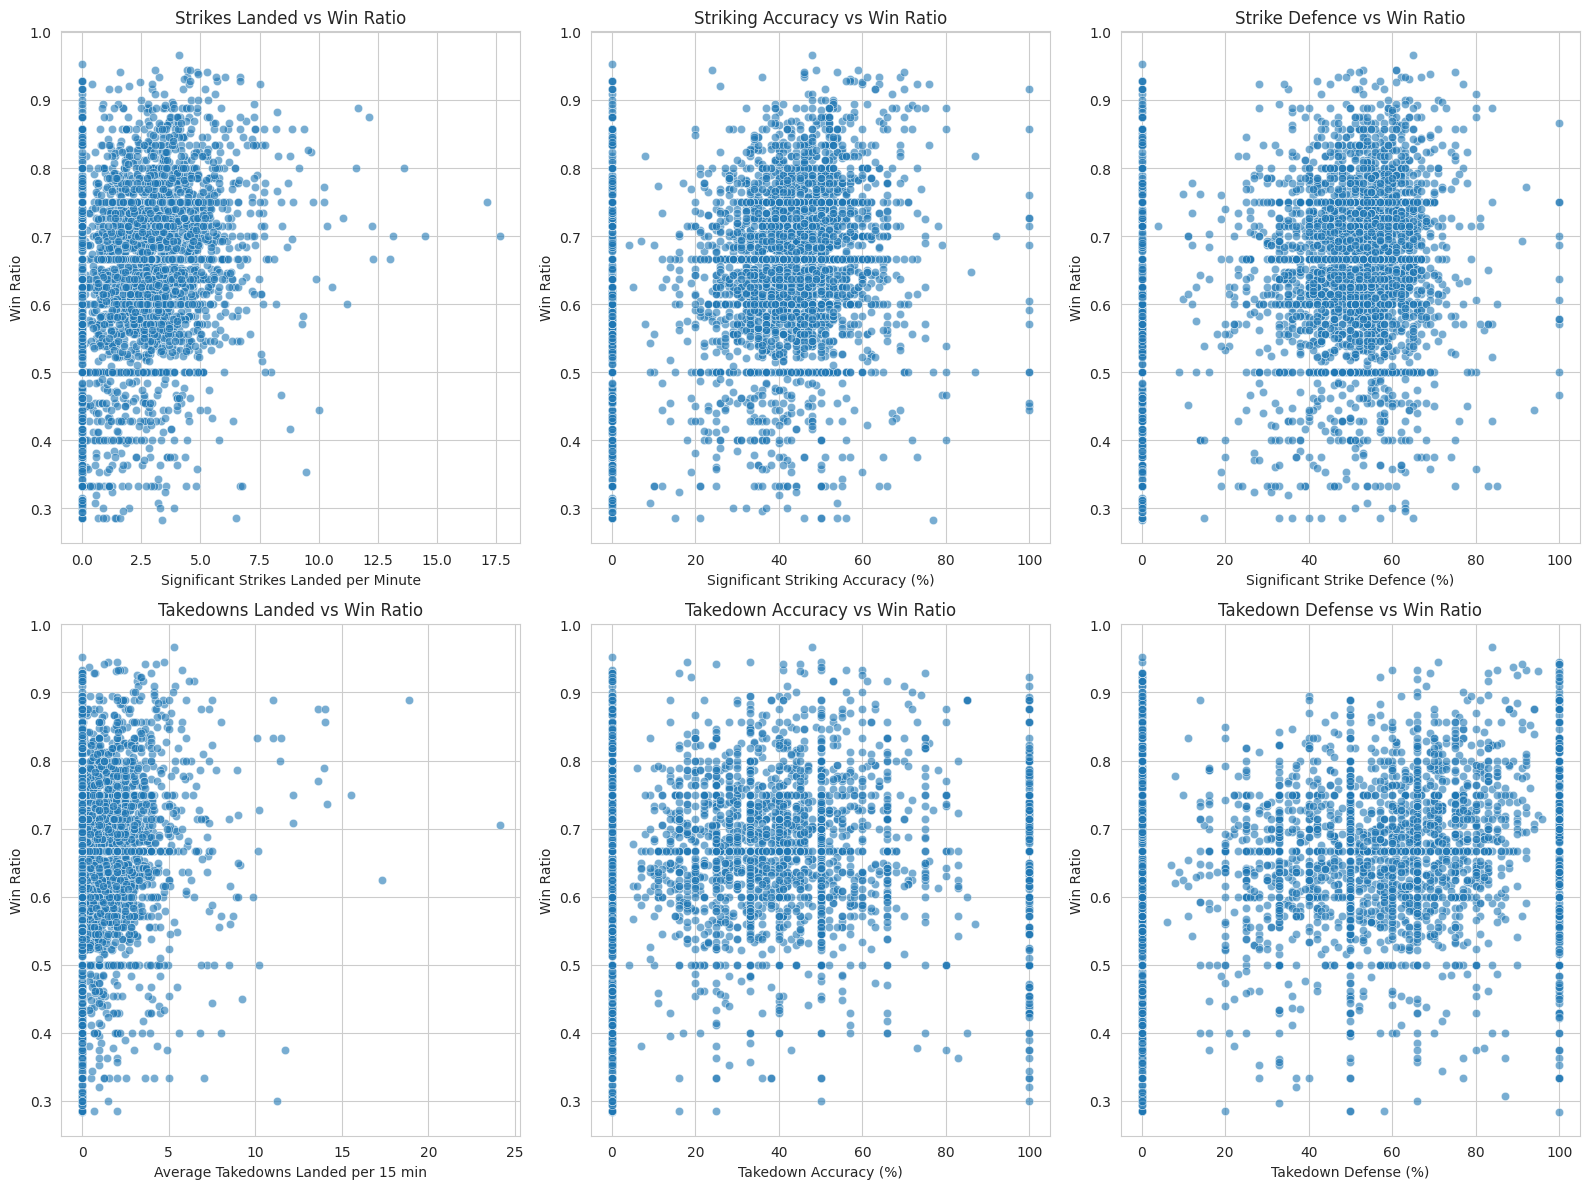

In [31]:
plt.figure(figsize=(16, 12))

# Striking metrics
plt.subplot(2, 3, 1)
sns.scatterplot(x='significant_strikes_landed_per_minute', y='win_ratio', data=ufc_df, alpha=0.6)
plt.title('Strikes Landed vs Win Ratio')
plt.xlabel('Significant Strikes Landed per Minute')
plt.ylabel('Win Ratio')

plt.subplot(2, 3, 2)
sns.scatterplot(x='significant_striking_accuracy', y='win_ratio', data=ufc_df, alpha=0.6)
plt.title('Striking Accuracy vs Win Ratio')
plt.xlabel('Significant Striking Accuracy (%)')
plt.ylabel('Win Ratio')

plt.subplot(2, 3, 3)
sns.scatterplot(x='significant_strike_defence', y='win_ratio', data=ufc_df, alpha=0.6)
plt.title('Strike Defence vs Win Ratio')
plt.xlabel('Significant Strike Defence (%)')
plt.ylabel('Win Ratio')

# Takedown metrics
plt.subplot(2, 3, 4)
sns.scatterplot(x='average_takedowns_landed_per_15_minutes', y='win_ratio', data=ufc_df, alpha=0.6)
plt.title('Takedowns Landed vs Win Ratio')
plt.xlabel('Average Takedowns Landed per 15 min')
plt.ylabel('Win Ratio')

plt.subplot(2, 3, 5)
sns.scatterplot(x='takedown_accuracy', y='win_ratio', data=ufc_df, alpha=0.6)
plt.title('Takedown Accuracy vs Win Ratio')
plt.xlabel('Takedown Accuracy (%)')
plt.ylabel('Win Ratio')

plt.subplot(2, 3, 6)
sns.scatterplot(x='takedown_defense', y='win_ratio', data=ufc_df, alpha=0.6)
plt.title('Takedown Defense vs Win Ratio')
plt.xlabel('Takedown Defense (%)')
plt.ylabel('Win Ratio')

plt.tight_layout()
plt.show()

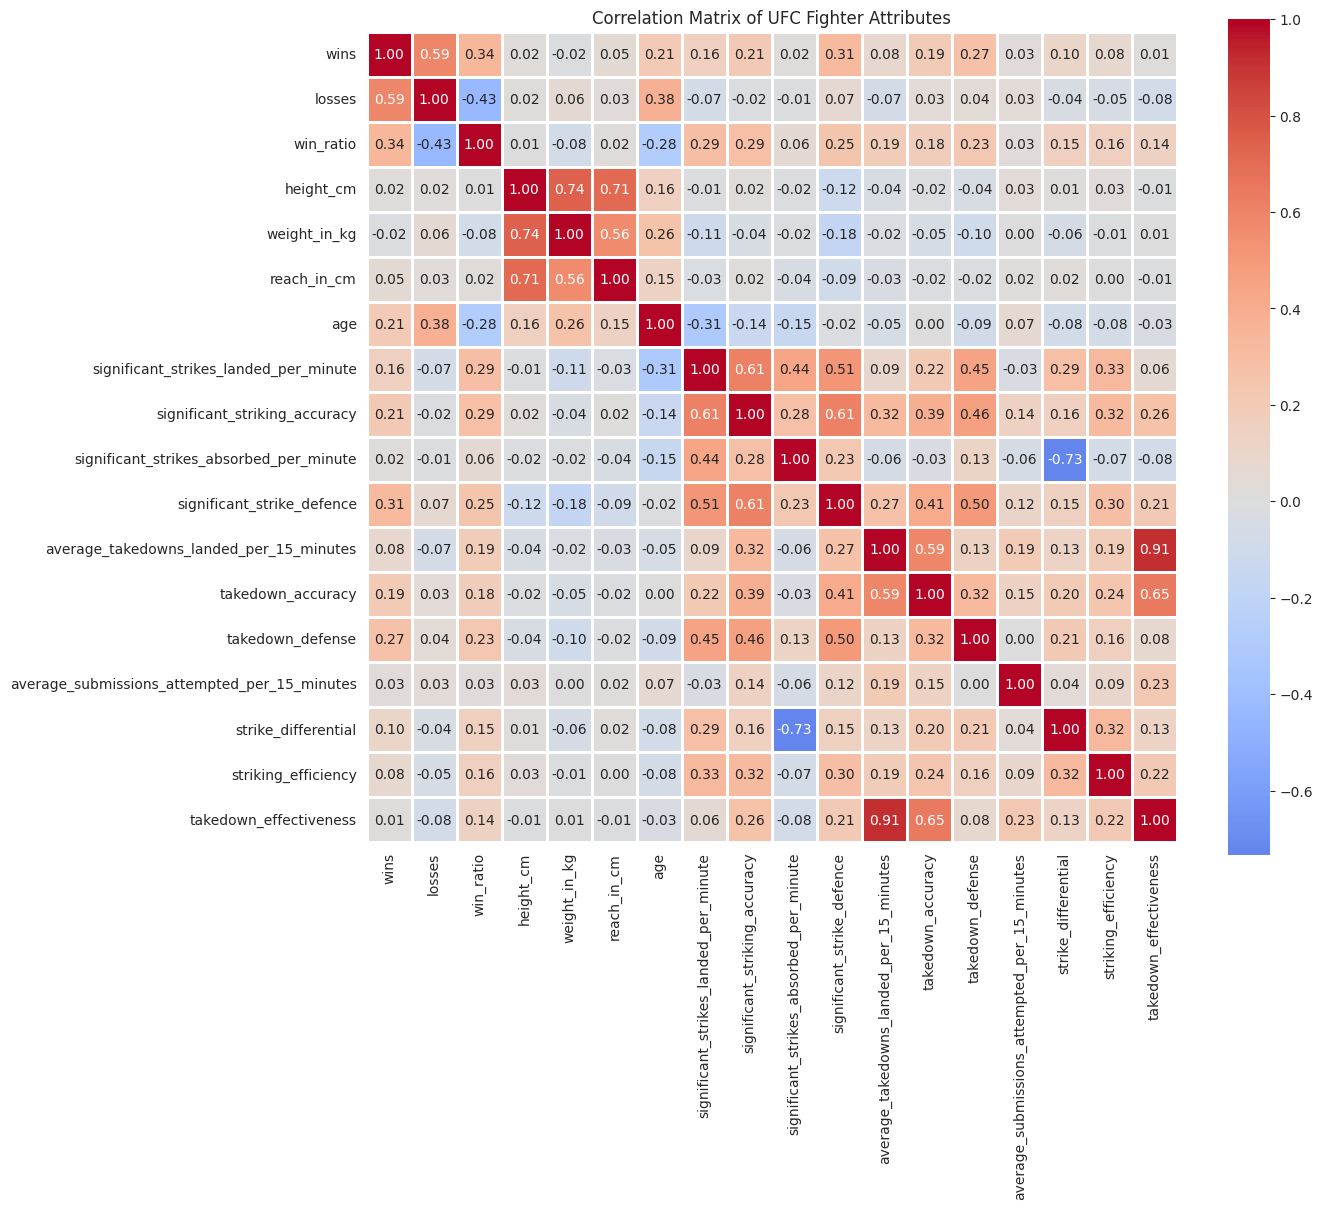


Top positive correlations with Win Ratio:
win_ratio                                  1.000000
wins                                       0.337303
significant_strikes_landed_per_minute      0.291769
significant_striking_accuracy              0.285591
significant_strike_defence                 0.246206
takedown_defense                           0.232040
average_takedowns_landed_per_15_minutes    0.191294
takedown_accuracy                          0.179642
striking_efficiency                        0.157258
strike_differential                        0.154841
Name: win_ratio, dtype: float64

Top negative correlations with Win Ratio:
reach_in_cm     0.023109
height_cm       0.007968
weight_in_kg   -0.078749
age            -0.282702
losses         -0.430201
Name: win_ratio, dtype: float64


In [32]:
# Select numerical columns for correlation
corr_cols = ['wins', 'losses', 'win_ratio', 'height_cm', 'weight_in_kg', 'reach_in_cm', 'age',
             'significant_strikes_landed_per_minute', 'significant_striking_accuracy',
             'significant_strikes_absorbed_per_minute', 'significant_strike_defence',
             'average_takedowns_landed_per_15_minutes', 'takedown_accuracy',
             'takedown_defense', 'average_submissions_attempted_per_15_minutes',
             'strike_differential', 'striking_efficiency', 'takedown_effectiveness']

corr_df = ufc_df[corr_cols]

# Correlation matrix
plt.figure(figsize=(14, 12))
correlation_matrix = corr_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, fmt='.2f')
plt.title('Correlation Matrix of UFC Fighter Attributes')
plt.tight_layout()
plt.show()

# Find top correlations with win_ratio
win_corr = correlation_matrix['win_ratio'].sort_values(ascending=False)
print("\nTop positive correlations with Win Ratio:")
print(win_corr.head(10))
print("\nTop negative correlations with Win Ratio:")
print(win_corr.tail(5))

In [33]:
#Machine Learning Analysis

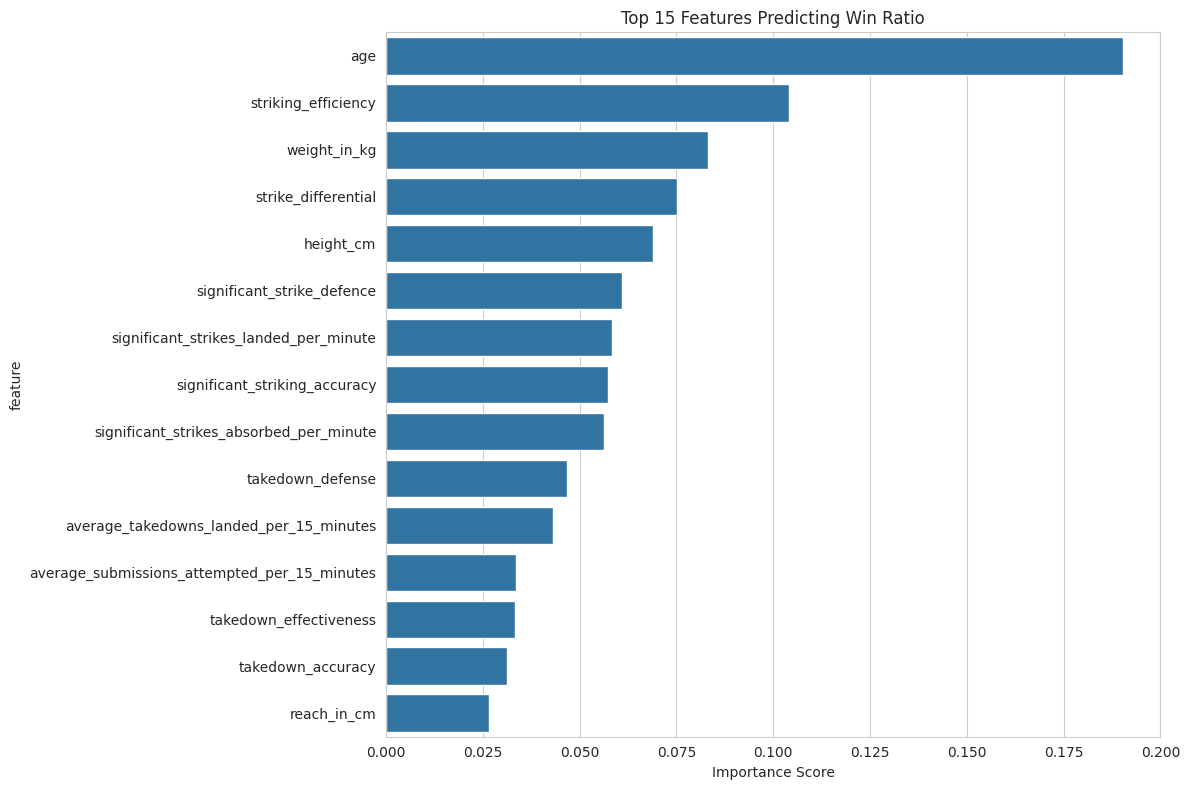

Top 10 Most Important Features:
                                    feature  importance
3                                       age    0.190485
13                      striking_efficiency    0.104090
1                              weight_in_kg    0.083138
12                      strike_differential    0.075259
0                                 height_cm    0.068848
7                significant_strike_defence    0.061052
4     significant_strikes_landed_per_minute    0.058426
5             significant_striking_accuracy    0.057190
6   significant_strikes_absorbed_per_minute    0.056307
10                         takedown_defense    0.046839


In [34]:
# Prepare features for modeling
feature_cols = ['height_cm', 'weight_in_kg', 'reach_in_cm', 'age',
                'significant_strikes_landed_per_minute', 'significant_striking_accuracy',
                'significant_strikes_absorbed_per_minute', 'significant_strike_defence',
                'average_takedowns_landed_per_15_minutes', 'takedown_accuracy',
                'takedown_defense', 'average_submissions_attempted_per_15_minutes',
                'strike_differential', 'striking_efficiency', 'takedown_effectiveness']

# Add stance as dummy variables
stance_dummies = pd.get_dummies(ufc_df['stance'], prefix='stance')
X = pd.concat([ufc_df[feature_cols], stance_dummies], axis=1)
y = ufc_df['win_ratio']

# Remove any remaining NaN values
X = X.fillna(X.median())
y = y.fillna(y.median())

# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance.head(15))
plt.title('Top 15 Features Predicting Win Ratio')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

In [35]:
# Binary classification (successful vs not successful)
y_class = (y > 0.5).astype(int)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.3, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Try different classifiers
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n{name} Accuracy: {accuracy:.3f}")
    print(classification_report(y_test, y_pred, target_names=['Not Successful', 'Successful']))


Logistic Regression Accuracy: 0.850
                precision    recall  f1-score   support

Not Successful       0.25      0.06      0.09       144
    Successful       0.87      0.97      0.92       926

      accuracy                           0.85      1070
     macro avg       0.56      0.51      0.50      1070
  weighted avg       0.79      0.85      0.81      1070


Random Forest Accuracy: 0.859
                precision    recall  f1-score   support

Not Successful       0.45      0.21      0.28       144
    Successful       0.89      0.96      0.92       926

      accuracy                           0.86      1070
     macro avg       0.67      0.58      0.60      1070
  weighted avg       0.83      0.86      0.84      1070



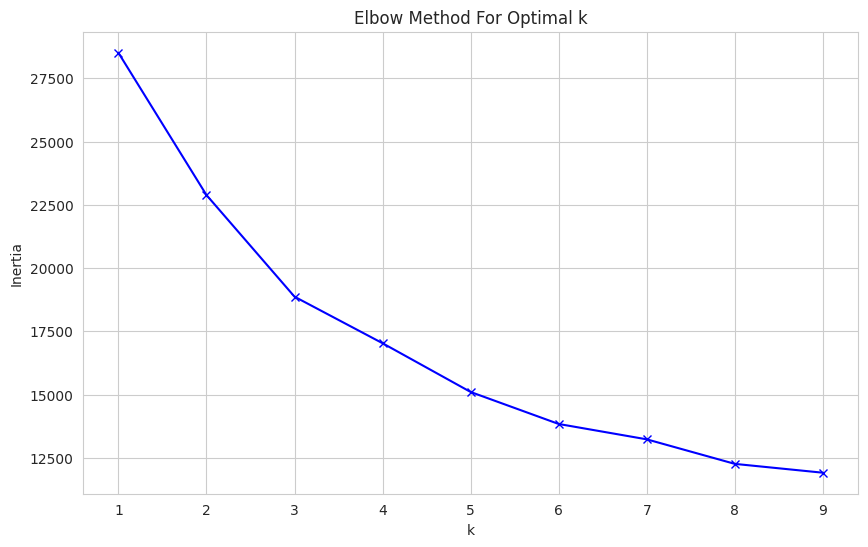


Cluster Profiles:
                  height_cm  weight_in_kg  reach_in_cm        age  \
fighter_cluster                                                     
0                186.837086     90.340199   190.598057  35.998755   
1                169.942312     61.986018   174.565578  33.868807   
2                178.543348     75.935756   183.118639  41.822894   
3                178.942148     79.784228   183.036832  38.582550   

                 significant_strikes_landed_per_minute  \
fighter_cluster                                          
0                                             3.878132   
1                                             3.568000   
2                                             2.212430   
3                                             0.382054   

                 significant_striking_accuracy  takedown_accuracy  \
fighter_cluster                                                     
0                                    48.521793          29.471980   
1         

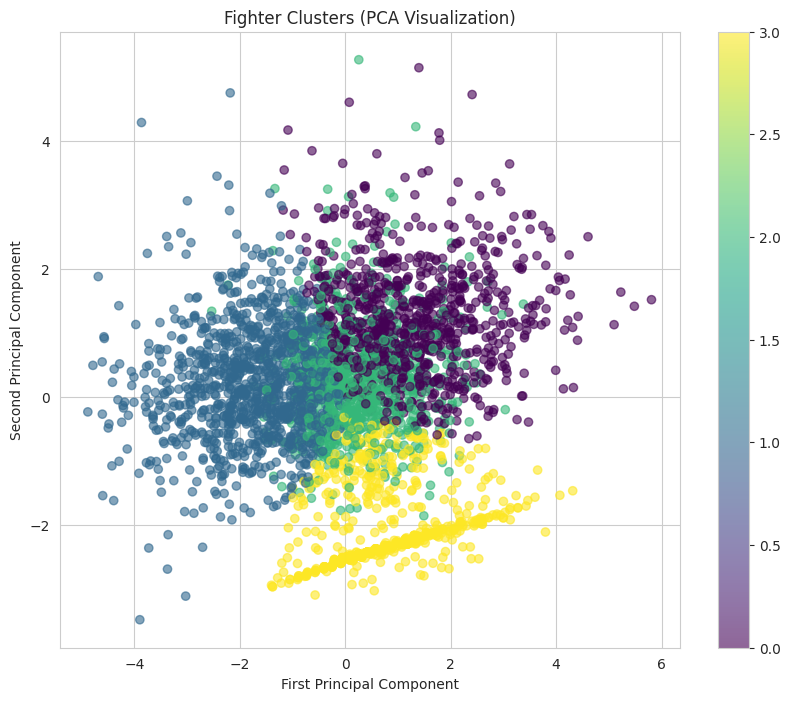

In [36]:
# Select features for clustering
cluster_features = ['height_cm', 'weight_in_kg', 'reach_in_cm', 'age',
                    'significant_strikes_landed_per_minute', 'significant_striking_accuracy',
                    'takedown_accuracy', 'average_submissions_attempted_per_15_minutes']

cluster_df = ufc_df[cluster_features].dropna()
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_df)

# Find optimal number of clusters using elbow method
inertias = []
K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(cluster_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K, inertias, 'bx-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

# Apply K-means with optimal k (let's say 4)
kmeans = KMeans(n_clusters=4, random_state=42)
ufc_df['fighter_cluster'] = kmeans.fit_predict(cluster_scaled)

# Analyze clusters
cluster_profile = ufc_df.groupby('fighter_cluster')[cluster_features].mean()
print("\nCluster Profiles:")
print(cluster_profile)

# Visualize clusters using PCA
pca = PCA(n_components=2)
cluster_pca = pca.fit_transform(cluster_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(cluster_pca[:, 0], cluster_pca[:, 1],
                      c=ufc_df['fighter_cluster'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter)
plt.title('Fighter Clusters (PCA Visualization)')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.show()